Name :- Sandesh Arun Mohite

Roll No :- 23

Division :- T.Y(AIML)-A



# **Multiclass Classification using Logistic Regression :-**

##Assignment :-

Predict Fruit Type (Apple, Orange, Banana) based on:

Weight

Sweetness

Size



## Step 1: Import Required Libraries


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


## Step 2: Create a Simple Multiclass Dataset
Target Variable:
Classes:

Apple → Apple

Orange → Orange

Banana → Banana


In [2]:
data = {
    'Weight_g': [
        150, 160, 170, 145, 180, 155, 165, 175, 140, 185,
        200, 210, 190, 220, 205, 215, 195, 225, 230, 185,
        110, 120, 125, 115, 130, 105, 135, 118, 128, 122
    ],

    'Sweetness': [
        6.2, 6.5, 6.8, 5.9, 7.0, 6.3, 6.7, 6.9, 5.8, 7.1,
        7.5, 7.8, 7.2, 8.0, 7.6, 7.9, 7.3, 8.2, 8.4, 7.0,
        8.5, 8.8, 9.0, 8.6, 9.2, 8.3, 9.4, 8.7, 9.1, 8.9
    ],

    'Size_cm': [
        7.0, 7.2, 7.5, 6.8, 7.8, 7.1, 7.4, 7.6, 6.7, 7.9,
        8.0, 8.2, 7.8, 8.5, 8.1, 8.4, 7.9, 8.6, 8.8, 7.7,
        12.0, 13.0, 13.5, 12.5, 14.0, 11.8, 14.5, 12.8, 13.8, 13.2
    ],

    'Fruit': [
        'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple', 'Apple',
        'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange', 'Orange',
        'Banana', 'Banana', 'Banana', 'Banana', 'Banana', 'Banana', 'Banana', 'Banana', 'Banana', 'Banana'
    ]
}

df = pd.DataFrame(data)
df


,Weight_g,Sweetness,Size_cm,Fruit
0,150,6.2,7.0,Apple
1,160,6.5,7.2,Apple
2,170,6.8,7.5,Apple
3,145,5.9,6.8,Apple
4,180,7.0,7.8,Apple
5,155,6.3,7.1,Apple
6,165,6.7,7.4,Apple
7,175,6.9,7.6,Apple
8,140,5.8,6.7,Apple
9,185,7.1,7.9,Apple



## Step 3: Explore the Dataset


In [3]:
df.shape

(30, 4)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Weight_g   30 non-null     int64  
 1   Sweetness  30 non-null     float64
 2   Size_cm    30 non-null     float64
 3   Fruit      30 non-null     object 
dtypes: float64(2), int64(1), object(1)
memory usage: 1.1+ KB


In [5]:
df.describe()

,Weight_g,Sweetness,Size_cm
count,30.000000,30.000000,30.000000
mean,163.600000,7.686667,9.536667
std,38.279012,1.048392,2.659204
min,105.000000,5.800000,6.700000
25%,128.500000,6.925000,7.625000
50%,162.500000,7.700000,8.150000
75%,193.750000,8.575000,12.375000
max,230.000000,9.400000,14.500000



## Step 4: Split Features and Target


In [6]:
X = df[['Weight_g', 'Sweetness', 'Size_cm']]
y = df['Fruit']



## Step 5: Train-Test Split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Step 6: Create and Train Logistic Regression Model


In [8]:
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')


## Step 7: Model Prediction and Evaluation


In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8333333333333334
Classification Report:
               precision    recall  f1-score   support

       Apple       1.00      0.50      0.67         2
      Banana       1.00      1.00      1.00         2
      Orange       0.67      1.00      0.80         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6




## Step 8: Visualization


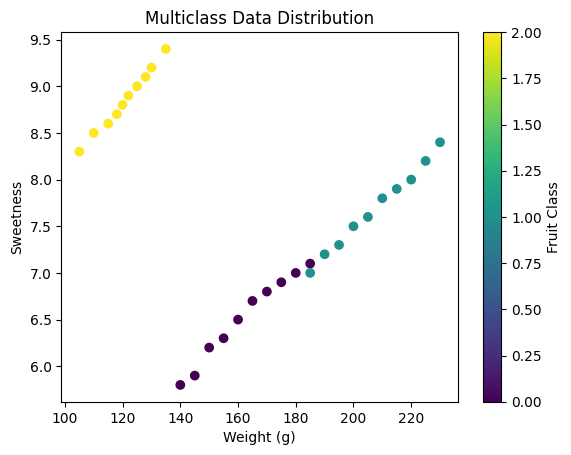

In [10]:
fruit_codes = df['Fruit'].map({'Apple': 0, 'Orange': 1, 'Banana': 2})

plt.scatter(df['Weight_g'], df['Sweetness'], c=fruit_codes, cmap='viridis')
plt.xlabel('Weight (g)')
plt.ylabel('Sweetness')
plt.title('Multiclass Data Distribution')
plt.colorbar(label='Fruit Class')
plt.show()



## Step 9: Prediction Using User Input


In [11]:
Weight_g = float(input("Enter Weight in grams: "))
Sweetness = float(input("Enter Sweetness: "))
Size_cm = float(input("Enter Size in cm: "))

new_data = [[Weight_g, Sweetness, Size_cm]]
prediction = model.predict(new_data)

print("Predicted Fruit Type:", prediction[0])


Enter Weight in grams: 50
Enter Sweetness: 4.9
Enter Size in cm: 5.7
Predicted Fruit Type: Banana


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [12]:
import pickle

In [13]:
pickle.dump(model,open('MCModel.pkl','wb'))

**Flask Code**

Save this file with 'app.py'

In [14]:
from flask import Flask, render_template, request
import pickle

app = Flask(__name__)

# Load Trained Model
model = pickle.load(open("MCModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read input values
    weight_g = float(request.form['weight_g'])
    sweetness = float(request.form['sweetness'])
    size_cm = float(request.form['size_cm'])

    # Prediction
    prediction = model.predict([[weight_g, sweetness, size_cm]])

    # Convert class into fruit type
    fruit = prediction[0]

    return render_template(
        "index.html",
        prediction_text=f"Predicted Fruit Type : {fruit}"
    )


if __name__ == "__main__":
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code**

Save this file with 'index.html'

In [15]:
<!DOCTYPE html>
<html lang="en">

<head>

<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">

<title>Fruit Type Predictor</title>

<style>

*{
    margin:0;
    padding:0;
    box-sizing:border-box;
    font-family:Arial, Helvetica, sans-serif;
}

body{
    background:#eef5ff;
    display:flex;
    justify-content:center;
    align-items:center;
    min-height:100vh;
}

.container{
    width:480px;
    background:white;
    padding:35px;
    border-radius:15px;
    box-shadow:0px 10px 25px rgba(0,0,0,.2);
}

h1{
    text-align:center;
    color:#1565c0;
}

h3{
    text-align:center;
    color:#555;
    margin-top:8px;
    margin-bottom:25px;
}

label{
    font-weight:bold;
    display:block;
    margin-top:15px;
    margin-bottom:6px;
}

input{
    width:100%;
    padding:12px;
    border:1px solid #ccc;
    border-radius:8px;
    font-size:16px;
}

button{
    width:100%;
    margin-top:25px;
    padding:13px;
    background:#1565c0;
    color:white;
    border:none;
    border-radius:8px;
    font-size:18px;
    cursor:pointer;
    transition:.3s;
}

button:hover{
    background:#0d47a1;
}

.result{
    margin-top:25px;
    background:#e8f5e9;
    padding:18px;
    border-radius:8px;
    text-align:center;
    color:green;
    font-size:21px;
    font-weight:bold;
}

footer{
    text-align:center;
    margin-top:20px;
    color:#777;
    font-size:13px;
}

</style>

</head>

<body>

<div class="container">

<h1>Fruit Type Predictor</h1>

<h3>Multiclass Classification using Logistic Regression</h3>

<form action="/predict" method="POST">

<label>Weight (g)</label>

<input
type="number"
name="weight_g"
step="0.1"
min="1"
placeholder="Enter Weight"
required>

<label>Sweetness</label>

<input
type="number"
name="sweetness"
step="0.1"
min="0"
placeholder="Enter Sweetness"
required>

<label>Size (cm)</label>

<input
type="number"
name="size_cm"
step="0.1"
min="1"
placeholder="Enter Size"
required>

<button type="submit">
Predict Fruit
</button>

</form>

{% if prediction_text %}

<div class="result">
{{ prediction_text }}
</div>

{% endif %}

<footer>
Fruit Type Prediction
</footer>

</div>

</body>

</html>


SyntaxError: invalid decimal literal (476398310.py, line 25)